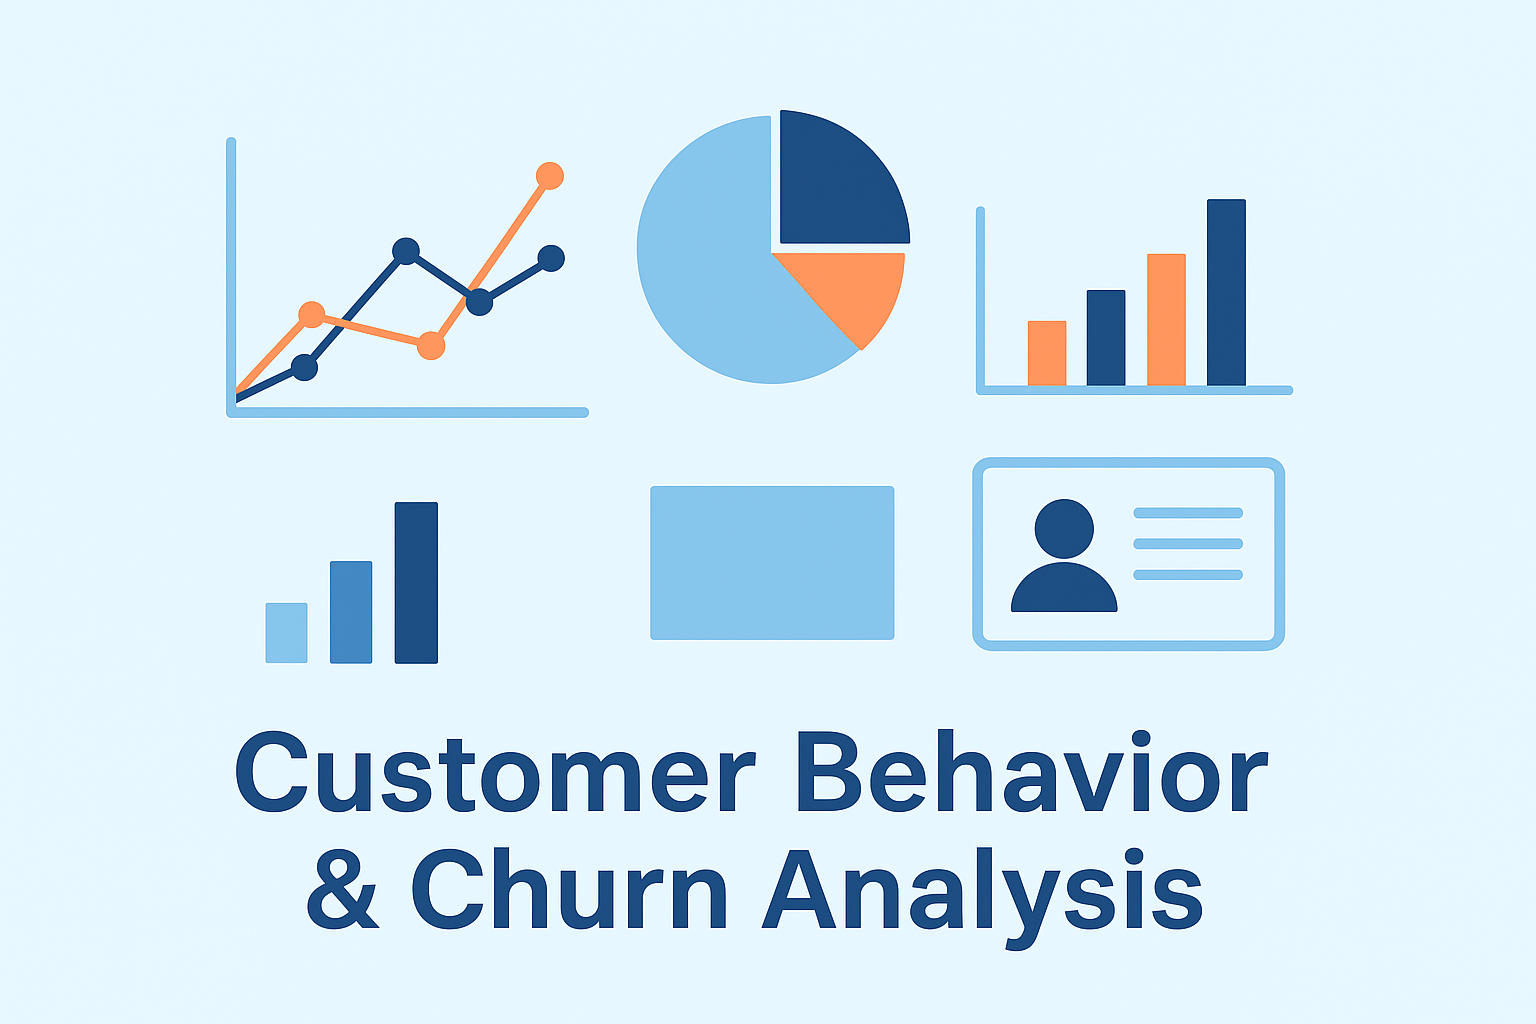

In [1]:
# @title
from IPython.display import display, HTML, Image
img = Image(filename=r"/content/ChatGPT Image Oct 27, 2025, 12_25_38 AM.png", width=1300,height=550)

display(HTML("<div style='text-align:center;'>"))
display(img)
display(HTML("</div>"))


In [2]:
# @title
from IPython.display import HTML, display

display(HTML("""
<center>
  <h1 style="
      background: linear-gradient(to right, #1f77b4, #ff8c42);
      -webkit-background-clip: text;
      -webkit-text-fill-color: transparent;
      font-family: 'Segoe UI', Arial, sans-serif;
      font-size: 40px;
      font-weight: 700;
      margin: 0;
  ">
    Final Project: End-to-End Data Analysis in Python
  </h1>
  <p style="color:#6b7280; font-family: Arial; margin-top:6px;">Customer & Call Center Insights Dashboard</p>
</center>
"""))

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


# **Project Overview**




# Telecom Customer and Call-Center Data Analysis
**Author:** Thekra Abu Halimeh — **Date:** 10/27/2025
## Overview

Customer satisfaction and retention are major challenges for telecom companies. This project performs an **exploratory data analysis (EDA)** on two datasets: one about **telecom customer churn** and another about **call-center performance**. The goal is to uncover insights that can help improve service quality and customer experience.

### Objectives
- Explore and understand the structure of both datasets.
- Identify and handle missing values or inconsistencies.
- Analyze customer churn trends and related factors.
- Evaluate call-center performance using key metrics such as satisfaction score and response time.
- Visualize findings using Python libraries.

### Datasets
- **Telecom Churn Rate Dataset:** Contains customer demographics, service details, and churn information.
- **Telecom Call-Center Dataset:** Includes agent performance, call duration, and satisfaction scores.

### Tools & Libraries
Python, pandas, NumPy, matplotlib, Plotly, and seaborn.

### Expected Outcomes
By the end of this analysis, we will have:
- Cleaned and validated datasets.
- Descriptive statistics and visual summaries.
- Clear insights on customer churn and call-center performance to guide decision-making.










# **Telecom Customer Data Overview**

In [4]:
df_churn_rate = pd.read_excel("/content/Telecom Churn Rate Dataset.xlsx")

In [5]:
df_churn_rate.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,0,0,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,0,0,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0,0,Yes


In [6]:
df_churn_rate.shape

(7043, 23)

In [7]:
df_churn_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
print(df_churn_rate.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
numAdminTickets       int64
numTechTickets        int64
Churn                object
dtype: object


In [9]:
df_churn_rate.columns.to_list()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'numAdminTickets',
 'numTechTickets',
 'Churn']

In [10]:
df_churn_rate.describe()

,SeniorCitizen,tenure,MonthlyCharges,numAdminTickets,numTechTickets
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,0.515689,0.419566
std,0.368612,24.559481,30.090047,1.275299,1.250117
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,0.000000,0.000000
50%,0.000000,29.000000,70.350000,0.000000,0.000000
75%,0.000000,55.000000,89.850000,0.000000,0.000000
max,1.000000,72.000000,118.750000,5.000000,9.000000


In [11]:
df_churn_rate.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [12]:
print(df_churn_rate['Churn'].unique())
print(df_churn_rate['StreamingTV'].unique())
print(df_churn_rate['InternetService'].unique())
print(df_churn_rate['DeviceProtection'].unique())

['No' 'Yes']
['No' 'Yes' 'No internet service']
['DSL' 'Fiber optic' 'No']
['No' 'Yes' 'No internet service']


# **Data Cleaning and Preparation**

In [13]:
print(df_churn_rate.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
numAdminTickets     0
numTechTickets      0
Churn               0
dtype: int64


In [14]:
df_churn_rate[df_churn_rate.duplicated()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn


In [15]:
df_churn_rate['TotalCharges'] = df_churn_rate['TotalCharges'].replace(" ", np.nan)
df_churn_rate['TotalCharges'] = df_churn_rate['TotalCharges'].astype(float)
df_churn_rate['TotalCharges'].fillna(df_churn_rate['TotalCharges'].mean(), inplace=True)

/tmp/ipython-input-3968133336.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_churn_rate['TotalCharges'] = df_churn_rate['TotalCharges'].replace(" ", np.nan)
/tmp/ipython-input-3968133336.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_churn_rate['TotalCharges'].fillna(df_churn_rate['T

In [16]:
df_churn_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# **Telecom Customer Analysis**
  - Exploratory Data Analysis (EDA)

In [17]:
# Churn distribution
churn_percent = df_churn_rate.groupby('Churn').size() / len(df_churn_rate) * 100
print(f"Churned Vs not Churned :\n{churn_percent}\n")
print("-------------------------------------------------------------------------------")
# Exploratory Data Analysis (EDA)
print("Average Monthly Charges:", df_churn_rate['MonthlyCharges'].mean())
print("Average Total Charges:", df_churn_rate['TotalCharges'].mean())
print("Average Tenure (months):", df_churn_rate['tenure'].mean(),"\n")
print("-------------------------------------------------------------------------------")
# Average charge per month
df_churn_rate['AvgChargePerMonth'] = np.where(df_churn_rate['tenure'] > 0, df_churn_rate['TotalCharges'] / df_churn_rate['tenure'], df_churn_rate['MonthlyCharges'])
print("Average Charge per Month:", df_churn_rate['AvgChargePerMonth'].mean())
print("-------------------------------------------------------------------------------")
# Ticket ratio (tickets per month)
df_churn_rate['Total_Tickets'] = df_churn_rate['numAdminTickets'] + df_churn_rate['numTechTickets']
df_churn_rate['Tickets_Ratio'] = np.where(df_churn_rate['tenure'] > 0, df_churn_rate['Total_Tickets'] / df_churn_rate['tenure'], 0)
print("Average Tickets Ratio:", df_churn_rate['Tickets_Ratio'].mean())


Churned Vs not Churned :
Churn
No     73.463013
Yes    26.536987
dtype: float64

-------------------------------------------------------------------------------
Average Monthly Charges: 64.76169246059918
Average Total Charges: 2283.3004408418656
Average Tenure (months): 32.37114865824223 

-------------------------------------------------------------------------------
Average Charge per Month: 64.76290591667771
-------------------------------------------------------------------------------
Average Tickets Ratio: 0.09955584166717282


In [18]:
df_churn_rate['Is_It_Senior?'] = df_churn_rate['SeniorCitizen'].apply(lambda x: 'Yes' if x == 1 else 'No')
df_churn_rate['Total_Tickets'] = df_churn_rate['numAdminTickets'] + df_churn_rate['numTechTickets']
df_churn_rate.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn,AvgChargePerMonth,Total_Tickets,Tickets_Ratio,Is_It_Senior?
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Electronic check,29.85,29.85,0,0,No,29.850000,0,0.000000,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Mailed check,56.95,1889.50,0,0,No,55.573529,0,0.000000,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Mailed check,53.85,108.15,0,0,Yes,54.075000,0,0.000000,No
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Bank transfer (automatic),42.30,1840.75,0,3,No,40.905556,3,0.066667,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Electronic check,70.70,151.65,0,0,Yes,75.825000,0,0.000000,No
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Electronic check,99.65,820.50,0,0,Yes,102.562500,0,0.000000,No
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,Credit card (automatic),89.10,1949.40,0,0,No,88.609091,0,0.000000,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,Mailed check,29.75,301.90,0,0,No,30.190000,0,0.000000,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Electronic check,104.80,3046.05,0,2,Yes,108.787500,2,0.071429,No
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,Bank transfer (automatic),56.15,3487.95,0,0,No,56.257258,0,0.000000,No


In [19]:
df_churn_rate.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,AvgChargePerMonth,Total_Tickets,Tickets_Ratio
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441,0.515689,0.419566,64.762906,0.935255,0.099556
std,0.368612,24.559481,30.090047,2265.000258,1.275299,1.250117,30.189796,1.778667,0.471520
min,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,13.775000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,402.225000,0.000000,0.000000,35.935156,0.000000,0.000000
50%,0.000000,29.000000,70.350000,1400.550000,0.000000,0.000000,70.337500,0.000000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,0.000000,0.000000,90.174158,1.000000,0.041667
max,1.000000,72.000000,118.750000,8684.800000,5.000000,9.000000,121.400000,12.000000,6.000000


In [20]:
# Summarization & Aggregation Examples:

# Average Tenure by Contract Type
avg_tenure_by_contract = df_churn_rate.groupby('Contract').agg({'tenure': 'mean'})
print(f"Average Tenure by Contract Type:\n{avg_tenure_by_contract}\n")
print("------------------------------------------------------------------------")
# Average Total Charges by Internet Service
avg_total_charges_by_internet = df_churn_rate.groupby('InternetService').agg({'TotalCharges': 'mean'})
print(f"Average Total Charges by Internet Service:\n{avg_total_charges_by_internet}\n")
print("------------------------------------------------------------------------")
# Total revenue = sum of TotalCharges
total_revenue = df_churn_rate.groupby('Contract').agg({'TotalCharges': 'sum'})
print(f"Total revenue = sum of TotalCharges:\n{total_revenue}")

Average Tenure by Contract Type:
                   tenure
Contract                 
Month-to-month  18.036645
One year        42.044807
Two year        56.735103

------------------------------------------------------------------------
Average Total Charges by Internet Service:
                 TotalCharges
InternetService              
DSL               2120.126953
Fiber optic       3205.304570
No                 671.582374

------------------------------------------------------------------------
Total revenue = sum of TotalCharges:
                TotalCharges
Contract                    
Month-to-month  5.305862e+06
One year        4.469337e+06
Two year        6.306087e+06


In [21]:
# Number of Customers by Internet Service
num_customers = df_churn_rate.groupby('InternetService')['customerID'].count()
print(f"Number of Customers by Internet Service:\n{num_customers}\n")
print("-------------------------------------------------------------------")
# Churn Counts
churn_counts = df_churn_rate.groupby('Contract')['Churn'].value_counts()
print(f"Churn Counts:\n{churn_counts}\n")
print("--------------------------------------------------------------------")
# Full statistical summary of monthly charges per contract type
summary = df_churn_rate.groupby('Contract')['MonthlyCharges'].agg(['mean', 'median', 'max', 'min', 'std'])
print(f"The statistical summary of monthly charges per contract type:\n{summary}")

Number of Customers by Internet Service:
InternetService
DSL            2421
Fiber optic    3096
No             1526
Name: customerID, dtype: int64

-------------------------------------------------------------------
Churn Counts:
Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
Name: count, dtype: int64

--------------------------------------------------------------------
The statistical summary of monthly charges per contract type:
                     mean  median     max    min        std
Contract                                                   
Month-to-month  66.398490   73.25  117.45  18.75  26.926599
One year        65.048608   68.75  118.60  18.25  31.840539
Two year        60.770413   64.35  118.75  18.40  34.678865


In [22]:
df_churn_rate.shape

(7043, 27)

In [23]:
# Churned seniors
churned_seniors = df_churn_rate[(df_churn_rate['Churn'] == 'Yes') & (df_churn_rate['Is_It_Senior?'] == 'Yes')]
print(f"Churned seniors:\n{churned_seniors.head(3).set_index('customerID')}\n")

Churned seniors:
            gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
customerID                                                                  
8779-QRDMV    Male              1      No         No       1           No   
7495-OOKFY  Female              1     Yes         No       8          Yes   
1658-BYGOY    Male              1      No         No      18          Yes   

               MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
customerID                                                                ...   
8779-QRDMV  No phone service             DSL             No           No  ...   
7495-OOKFY               Yes     Fiber optic             No          Yes  ...   
1658-BYGOY               Yes     Fiber optic             No           No  ...   

                      PaymentMethod MonthlyCharges TotalCharges  \
customerID                                                        
8779-QRDMV         Electronic check          39.65       

In [24]:
# Customers who churned
churned_customers = df_churn_rate[df_churn_rate['Churn'] == 'Yes']
print(f"Customers who churned:\n{churned_customers.head(3).set_index('customerID')}\n")

Customers who churned:
            gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
customerID                                                                  
3668-QPYBK    Male              0      No         No       2          Yes   
9237-HQITU  Female              0      No         No       2          Yes   
9305-CDSKC  Female              0      No         No       8          Yes   

           MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
customerID                                                            ...   
3668-QPYBK            No             DSL            Yes          Yes  ...   
9237-HQITU            No     Fiber optic             No           No  ...   
9305-CDSKC           Yes     Fiber optic             No           No  ...   

               PaymentMethod MonthlyCharges TotalCharges numAdminTickets  \
customerID                                                                 
3668-QPYBK      Mailed check          53.85       108

In [25]:
# Churned high-paying customers
churned_high_paying = df_churn_rate[(df_churn_rate['Churn'] == 'Yes') & (df_churn_rate['MonthlyCharges'] > 70)]
print(f"Churned high-paying customers:\n{churned_high_paying.head(3).set_index('customerID')}\n")

Churned high-paying customers:
            gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
customerID                                                                  
9237-HQITU  Female              0      No         No       2          Yes   
9305-CDSKC  Female              0      No         No       8          Yes   
7892-POOKP  Female              0     Yes         No      28          Yes   

           MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
customerID                                                            ...   
9237-HQITU            No     Fiber optic             No           No  ...   
9305-CDSKC           Yes     Fiber optic             No           No  ...   
7892-POOKP           Yes     Fiber optic             No           No  ...   

               PaymentMethod MonthlyCharges TotalCharges numAdminTickets  \
customerID                                                                 
9237-HQITU  Electronic check          70.70  

In [26]:
# High-paying, senior customers with tech issues who churned
high_risk_customers = df_churn_rate[
    (df_churn_rate['MonthlyCharges'] > 70) &
    (df_churn_rate['SeniorCitizen'] == 1) &
    (df_churn_rate['numTechTickets'] > 0) &
    (df_churn_rate['Churn'] == 'Yes')
]
print(f"High-paying, senior customers with tech issues who churned:\n{high_risk_customers.head(3).set_index('customerID')}\n")


High-paying, senior customers with tech issues who churned:
            gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
customerID                                                                  
1658-BYGOY    Male              1      No         No      18          Yes   
4598-XLKNJ  Female              1     Yes         No      25          Yes   
3606-TWKGI    Male              1      No         No      13          Yes   

           MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
customerID                                                            ...   
1658-BYGOY           Yes     Fiber optic             No           No  ...   
4598-XLKNJ            No     Fiber optic             No          Yes  ...   
3606-TWKGI           Yes     Fiber optic             No          Yes  ...   

               PaymentMethod MonthlyCharges TotalCharges numAdminTickets  \
customerID                                                                 
1658-BYGOY  Elec

In [27]:
# Customers with long tenure but low satisfaction signals
possible_unhappy_longterm = df_churn_rate[
    (df_churn_rate['tenure'] > 36) &
    (df_churn_rate['AvgChargePerMonth'] > df_churn_rate['MonthlyCharges'])
]
print(f"Customers with long tenure but low satisfaction signals (AvgChargePerMonth > MonthlyCharges):\n{possible_unhappy_longterm.head(3).set_index('customerID')}\n")

Customers with long tenure but low satisfaction signals (AvgChargePerMonth > MonthlyCharges):
            gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
customerID                                                                  
6388-TABGU    Male              0      No        Yes      62          Yes   
3655-SNQYZ  Female              0     Yes        Yes      69          Yes   
3638-WEABW  Female              0     Yes         No      58          Yes   

           MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
customerID                                                            ...   
6388-TABGU            No             DSL            Yes          Yes  ...   
3655-SNQYZ           Yes     Fiber optic            Yes          Yes  ...   
3638-WEABW           Yes             DSL             No          Yes  ...   

                        PaymentMethod MonthlyCharges TotalCharges  \
customerID                                                       

# **Call Center Data Overview**

In [28]:
df_call_center = pd.read_excel("/content/Telecom Company Call-Center-Dataset.xlsx")

In [29]:
df_call_center.head()

,Call Id,Agent,Date,Time,Topic,Answered (Y/N),Resolved,Speed of answer in seconds,AvgTalkDuration,Satisfaction rating
0,ID0001,Diane,2021-01-01,09:12:58,Contract related,Y,Y,109.0,00:02:23,3.0
1,ID0002,Becky,2021-01-01,09:12:58,Technical Support,Y,N,70.0,00:04:02,3.0
2,ID0003,Stewart,2021-01-01,09:47:31,Contract related,Y,Y,10.0,00:02:11,3.0
3,ID0004,Greg,2021-01-01,09:47:31,Contract related,Y,Y,53.0,00:00:37,2.0
4,ID0005,Becky,2021-01-01,10:00:29,Payment related,Y,Y,95.0,00:01:00,3.0


In [30]:
print(df_call_center.shape)

(5000, 10)


In [31]:
df_call_center.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Call Id                     5000 non-null   object 
 1   Agent                       5000 non-null   object 
 2   Date                        5000 non-null   object 
 3   Time                        5000 non-null   object 
 4   Topic                       5000 non-null   object 
 5   Answered (Y/N)              5000 non-null   object 
 6   Resolved                    5000 non-null   object 
 7   Speed of answer in seconds  4054 non-null   float64
 8   AvgTalkDuration             4054 non-null   object 
 9   Satisfaction rating         4054 non-null   float64
dtypes: float64(2), object(8)
memory usage: 390.8+ KB


In [32]:
print(df_call_center.dtypes)

Call Id                        object
Agent                          object
Date                           object
Time                           object
Topic                          object
Answered (Y/N)                 object
Resolved                       object
Speed of answer in seconds    float64
AvgTalkDuration                object
Satisfaction rating           float64
dtype: object


In [33]:
df_call_center.columns.to_list()

['Call Id',
 'Agent',
 'Date',
 'Time',
 'Topic',
 'Answered (Y/N)',
 'Resolved',
 'Speed of answer in seconds',
 'AvgTalkDuration',
 'Satisfaction rating']

In [34]:
df_call_center.describe()

,Speed of answer in seconds,Satisfaction rating
count,4054.000000,4054.000000
mean,67.520720,3.403552
std,33.592872,1.212220
min,10.000000,1.000000
25%,39.000000,3.000000
50%,68.000000,3.000000
75%,97.000000,4.000000
max,125.000000,5.000000


In [35]:
df_call_center.nunique()

,0
Call Id,5000
Agent,8
Date,90
Time,375
Topic,5
Answered (Y/N),2
Resolved,2
Speed of answer in seconds,116
AvgTalkDuration,391
Satisfaction rating,5


In [36]:
df_call_center.duplicated().sum()

np.int64(0)

In [37]:
print(df_call_center['Topic'].unique())
print(df_call_center['Agent'].unique())
print(df_call_center['Satisfaction rating'].unique())
print(df_call_center['Resolved'].unique())

['Contract related' 'Technical Support' 'Payment related' 'Admin Support'
 'Streaming']
['Diane' 'Becky' 'Stewart' 'Greg' 'Jim' 'Joe' 'Martha' 'Dan']
[ 3.  2. nan  4.  5.  1.]
['Y' 'N']


# **Data Cleaning and Preparation**

In [38]:
print(df_call_center.isnull().sum())

Call Id                         0
Agent                           0
Date                            0
Time                            0
Topic                           0
Answered (Y/N)                  0
Resolved                        0
Speed of answer in seconds    946
AvgTalkDuration               946
Satisfaction rating           946
dtype: int64


In [39]:
df_call_center[df_call_center.duplicated()]

,Call Id,Agent,Date,Time,Topic,Answered (Y/N),Resolved,Speed of answer in seconds,AvgTalkDuration,Satisfaction rating


In [40]:
df_call_center['Speed of answer in seconds'].fillna(df_call_center['Speed of answer in seconds'].mean(), inplace=True)
df_call_center['Satisfaction rating'].fillna(df_call_center['Satisfaction rating'].mean(), inplace=True)

/tmp/ipython-input-3445720363.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_call_center['Speed of answer in seconds'].fillna(df_call_center['Speed of answer in seconds'].mean(), inplace=True)
/tmp/ipython-input-3445720363.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


In [41]:
df_call_center["AvgTalkDuration"] = df_call_center["AvgTalkDuration"].apply( lambda t: t.hour * 3600 + t.minute * 60 + t.second if pd.notnull(t) else np.nan)
df_call_center["AvgTalkDuration"].fillna(df_call_center["AvgTalkDuration"].mean(), inplace=True)
df_call_center["AvgTalkDuration"] = df_call_center["AvgTalkDuration"].astype(float)
df_call_center.rename(columns={'AvgTalkDuration': 'TalkDurationSeconds'}, inplace=True)

/tmp/ipython-input-4187452460.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_call_center["AvgTalkDuration"].fillna(df_call_center["AvgTalkDuration"].mean(), inplace=True)


In [42]:
df_call_center['Time'] = df_call_center['Time'].astype(str)
df_call_center['DateTime'] = pd.to_datetime(df_call_center['Date'] + ' ' + df_call_center['Time'])

In [43]:
df_call_center['Hour'] = df_call_center['DateTime'].dt.hour
df_call_center['Minute'] = df_call_center['DateTime'].dt.minute

In [44]:
df_call_center.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Call Id                     5000 non-null   object        
 1   Agent                       5000 non-null   object        
 2   Date                        5000 non-null   object        
 3   Time                        5000 non-null   object        
 4   Topic                       5000 non-null   object        
 5   Answered (Y/N)              5000 non-null   object        
 6   Resolved                    5000 non-null   object        
 7   Speed of answer in seconds  5000 non-null   float64       
 8   TalkDurationSeconds         5000 non-null   float64       
 9   Satisfaction rating         5000 non-null   float64       
 10  DateTime                    5000 non-null   datetime64[ns]
 11  Hour                        5000 non-null   int32       

In [45]:
df_call_center.drop('Time', axis=1, inplace=True)
df_call_center.drop('Date', axis=1, inplace=True)

In [46]:
print(df_call_center.head())

  Call Id    Agent              Topic Answered (Y/N) Resolved  \
0  ID0001    Diane   Contract related              Y        Y   
1  ID0002    Becky  Technical Support              Y        N   
2  ID0003  Stewart   Contract related              Y        Y   
3  ID0004     Greg   Contract related              Y        Y   
4  ID0005    Becky    Payment related              Y        Y   

   Speed of answer in seconds  TalkDurationSeconds  Satisfaction rating  \
0                       109.0                143.0                  3.0   
1                        70.0                242.0                  3.0   
2                        10.0                131.0                  3.0   
3                        53.0                 37.0                  2.0   
4                        95.0                 60.0                  3.0   

             DateTime  Hour  Minute  
0 2021-01-01 09:12:58     9      12  
1 2021-01-01 09:12:58     9      12  
2 2021-01-01 09:47:31     9      47  
3 2021

# **Call Center Analysis**

In [47]:
# grouping and aggregation tasks to extract real business insights:

# Average performance per agent
agent_summary = df_call_center.groupby('Agent').agg({'Speed of answer in seconds': 'mean','TalkDurationSeconds': 'mean','Satisfaction rating': 'mean'}).round(2)
print(f"Average performance per agent:\n{agent_summary}\n")
print("-------------------------------------------------------------------------------")
# Total and average speed of answer by topic
topic_summary = df_call_center.groupby('Topic').agg({'Speed of answer in seconds': ['mean', 'min', 'max'],'Satisfaction rating': 'mean'}).round(2)
print(f"Total and average speed of answer by topic:\n{topic_summary}\n")
print("-------------------------------------------------------------------------------")
# Average satisfaction by whether the issue was resolved
resolution_summary = df_call_center.groupby('Resolved').agg({'Satisfaction rating': 'mean'}).round(2)
print(f"Average satisfaction if the issue was resolved:\n{resolution_summary}")
print("-------------------------------------------------------------------------------")
# Find which agents resolve the most calls successfully
resolution_rate = (df_call_center.groupby('Agent')['Resolved'].apply(lambda x: (x == 'Y').mean()*100).round(2))
print(f"Resolution rate by agent:\n{resolution_rate}")

Average performance per agent:
         Speed of answer in seconds  TalkDurationSeconds  Satisfaction rating
Agent                                                                        
Becky                         65.73               220.90                 3.38
Dan                           67.32               230.10                 3.44
Diane                         66.53               220.20                 3.40
Greg                          68.26               226.44                 3.40
Jim                           66.57               227.49                 3.40
Joe                           70.35               224.25                 3.34
Martha                        69.11               223.96                 3.46
Stewart                       66.43               225.97                 3.40

-------------------------------------------------------------------------------
Total and average speed of answer by topic:
                  Speed of answer in seconds              Satisf

In [48]:
df_call_center['Efficiency'] = df_call_center['TalkDurationSeconds'] / df_call_center['Speed of answer in seconds']
print(f"Efficiency:\n{df_call_center['Efficiency']}\n")
print("---------------------------------------------------")
df_call_center['Resolved_status'] = df_call_center['Resolved'].apply(lambda x: 1 if x == 'Y' else 0)
print(f"ResolvedFlag 1 if Resolved == 'Y':\n{df_call_center['Resolved_status']}\n")
print("---------------------------------------------------")
df_call_center['HighSatisfaction'] = df_call_center['Satisfaction rating'].apply(lambda x: 1 if x >= 4 else 0)
print(f"HighSatisfaction 1 if Satisfaction rating >= 4:\n{df_call_center['HighSatisfaction']}")

Efficiency:
0        1.311927
1        3.457143
2       13.100000
3        0.698113
4        0.631579
          ...    
4995    15.454545
4996     1.960000
4997     1.297619
4998     0.591837
4999     3.331167
Name: Efficiency, Length: 5000, dtype: float64

---------------------------------------------------
ResolvedFlag 1 if Resolved == 'Y':
0       1
1       0
2       1
3       1
4       1
       ..
4995    1
4996    1
4997    1
4998    1
4999    0
Name: Resolved_status, Length: 5000, dtype: int64

---------------------------------------------------
HighSatisfaction 1 if Satisfaction rating >= 4:
0       0
1       0
2       0
3       0
4       0
       ..
4995    0
4996    0
4997    1
4998    1
4999    0
Name: HighSatisfaction, Length: 5000, dtype: int64


In [49]:
# Calls with very fast efficiency
high_efficiency_calls = df_call_center[df_call_center['Efficiency'] > 5]
print(f"Calls with very fast efficiency (high TalkDurationSeconds relative to Speed of Answer):\n{high_efficiency_calls.head(3).set_index('Call Id')}\n")

Calls with very fast efficiency (high TalkDurationSeconds relative to Speed of Answer):
           Agent             Topic Answered (Y/N) Resolved  \
Call Id                                                      
ID0003   Stewart  Contract related              Y        Y   
ID0007     Diane   Payment related              Y        Y   
ID0009      Greg     Admin Support              Y        Y   

         Speed of answer in seconds  TalkDurationSeconds  Satisfaction rating  \
Call Id                                                                         
ID0003                         10.0                131.0                  3.0   
ID0007                         24.0                220.0                  2.0   
ID0009                         15.0                398.0                  4.0   

                   DateTime  Hour  Minute  Efficiency  Resolved_status  \
Call Id                                                                  
ID0003  2021-01-01 09:47:31     9      47   13.

In [50]:
# Calls that were answered and resolved successfully
successful_calls = df_call_center[(df_call_center['Answered (Y/N)'] == 'Y') & (df_call_center['Resolved_status'] == 1)]
print(f"Calls that were answered and resolved successfully:\n{successful_calls.head(3).set_index('Call Id')}\n")

Calls that were answered and resolved successfully:
           Agent             Topic Answered (Y/N) Resolved  \
Call Id                                                      
ID0001     Diane  Contract related              Y        Y   
ID0003   Stewart  Contract related              Y        Y   
ID0004      Greg  Contract related              Y        Y   

         Speed of answer in seconds  TalkDurationSeconds  Satisfaction rating  \
Call Id                                                                         
ID0001                        109.0                143.0                  3.0   
ID0003                         10.0                131.0                  3.0   
ID0004                         53.0                 37.0                  2.0   

                   DateTime  Hour  Minute  Efficiency  Resolved_status  \
Call Id                                                                  
ID0001  2021-01-01 09:12:58     9      12    1.311927                1   
ID0003  2

In [51]:
# Calls with low satisfaction (rating <= 2)
low_satisfaction_calls = df_call_center[df_call_center['Satisfaction rating'] <= 2]
print(f"Calls with low satisfaction (rating <= 2):\n{low_satisfaction_calls.head(3).set_index('Call Id')}\n")

Calls with low satisfaction (rating <= 2):
         Agent             Topic Answered (Y/N) Resolved  \
Call Id                                                    
ID0004    Greg  Contract related              Y        Y   
ID0007   Diane   Payment related              Y        Y   
ID0016   Becky     Admin Support              Y        Y   

         Speed of answer in seconds  TalkDurationSeconds  Satisfaction rating  \
Call Id                                                                         
ID0004                         53.0                 37.0                  2.0   
ID0007                         24.0                220.0                  2.0   
ID0016                         63.0                326.0                  2.0   

                   DateTime  Hour  Minute  Efficiency  Resolved_status  \
Call Id                                                                  
ID0004  2021-01-01 09:47:31     9      47    0.698113                1   
ID0007  2021-01-01 10:22:05 

In [52]:
# Calls that were slow and unresolved
problematic_calls = df_call_center[(df_call_center['Speed of answer in seconds'] > 100) & (df_call_center['Resolved_status'] == 0)]
print(f"Calls that were slow and unresolved:\n{problematic_calls.head(3).set_index('Call Id')}\n")

Calls that were slow and unresolved:
           Agent              Topic Answered (Y/N) Resolved  \
Call Id                                                       
ID0075   Stewart  Technical Support              Y        N   
ID0119       Dan    Payment related              Y        N   
ID0136      Greg  Technical Support              Y        N   

         Speed of answer in seconds  TalkDurationSeconds  Satisfaction rating  \
Call Id                                                                         
ID0075                        125.0                 98.0                  3.0   
ID0119                        124.0                143.0                  5.0   
ID0136                        105.0                359.0                  3.0   

                   DateTime  Hour  Minute  Efficiency  Resolved_status  \
Call Id                                                                  
ID0075  2021-01-02 11:42:43    11      42    0.784000                0   
ID0119  2021-01-03 

In [53]:
# unresolved, low satisfaction, and slow
high_priority_calls = df_call_center[
    (df_call_center['Resolved_status'] == 0) &
    (df_call_center['Satisfaction rating'] <= 2) &
    (df_call_center['Speed of answer in seconds'] > 90)
]
print(f"High-priority cases: unresolved, low satisfaction, and slow:\n{high_priority_calls.head(3).set_index('Call Id')}\n")

High-priority cases: unresolved, low satisfaction, and slow:
         Agent             Topic Answered (Y/N) Resolved  \
Call Id                                                    
ID0576     Jim  Contract related              Y        N   
ID0942   Diane         Streaming              Y        N   
ID1131     Joe     Admin Support              Y        N   

         Speed of answer in seconds  TalkDurationSeconds  Satisfaction rating  \
Call Id                                                                         
ID0576                        122.0                168.0                  1.0   
ID0942                        113.0                165.0                  2.0   
ID1131                        100.0                244.0                  2.0   

                   DateTime  Hour  Minute  Efficiency  Resolved_status  \
Call Id                                                                  
ID0576  2021-01-10 17:39:50    17      39    1.377049                0   
ID0942  20

In [54]:
# Efficient but unsatisfactory calls
fast_low_satisfaction = df_call_center[
    (df_call_center['Efficiency'] > 5) &
    (df_call_center['HighSatisfaction'] == 0)
]
print(f"Efficient but unsatisfactory calls (maybe agent was fast but quality low):\n{fast_low_satisfaction.head(3).set_index('Call Id')}\n")

Efficient but unsatisfactory calls (maybe agent was fast but quality low):
           Agent             Topic Answered (Y/N) Resolved  \
Call Id                                                      
ID0003   Stewart  Contract related              Y        Y   
ID0007     Diane   Payment related              Y        Y   
ID0016     Becky     Admin Support              Y        Y   

         Speed of answer in seconds  TalkDurationSeconds  Satisfaction rating  \
Call Id                                                                         
ID0003                         10.0                131.0                  3.0   
ID0007                         24.0                220.0                  2.0   
ID0016                         63.0                326.0                  2.0   

                   DateTime  Hour  Minute  Efficiency  Resolved_status  \
Call Id                                                                  
ID0003  2021-01-01 09:47:31     9      47   13.100000       

In [55]:
df_churn_rate.to_excel("telecom_customer_churn.xlsx", index=False)

df_call_center.to_excel("call_center_data.xlsx", index=False)

# **Visualization Dashboard Summary**

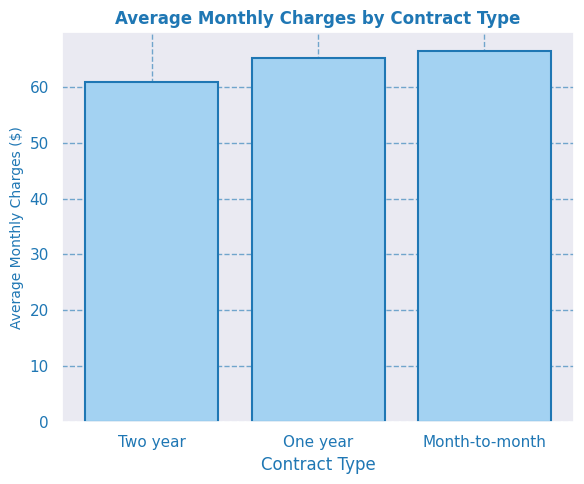

Month-to-month customers have the highest average monthly charges, suggesting that flexible contracts come with higher costs — possibly increasing churn risk.


In [56]:
soft_blue = '#a3d2f2'
orange = '#ff8c42'
col = '#1f77b4'
sns.set(style="darkgrid")
contract_avg = df_churn_rate.groupby('Contract')['MonthlyCharges'].mean().sort_values()
plt.figure(figsize=(6, 5))
bars = plt.bar(contract_avg.index, contract_avg.values, color=soft_blue, edgecolor=col, linewidth=1.5)

plt.title('Average Monthly Charges by Contract Type', fontsize=12, fontweight='bold', color=col)
plt.xlabel('Contract Type', fontsize=12, color=col)
plt.ylabel('Average Monthly Charges ($)', fontsize=10, color=col)
plt.xticks(rotation=0, color=col)
plt.yticks(color=col)
plt.grid(True, linestyle='--', alpha=0.6, color=col)
plt.tight_layout()
plt.show()
print('''Month-to-month customers have the highest average monthly charges, suggesting that flexible contracts come with higher costs — possibly increasing churn risk.''')

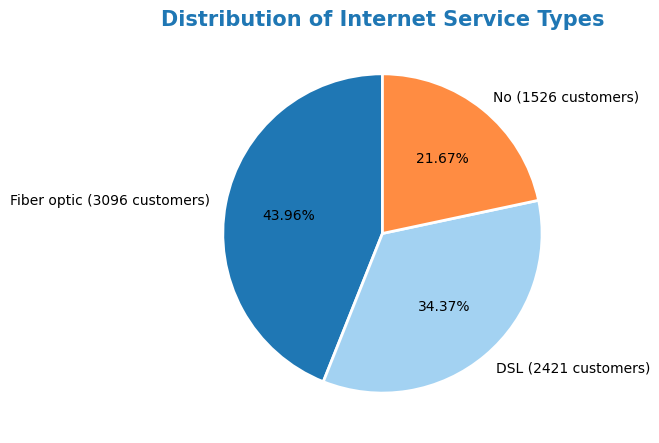

Most customers use Fiber optic service, followed by DSL, while a smaller portion has no internet service.
This shows that fiber is the most popular and possibly the most competitive segment,
where service quality and pricing may strongly influence churn behavior.


In [57]:
soft_blue = '#a3d2f2'
orange = '#ff8c42'
col = '#1f77b4'
sns.set(style="darkgrid")
internet_counts = df_churn_rate['InternetService'].value_counts()

labels = [
    f"{service} ({count} customers)"
    for service, count in zip(internet_counts.index, internet_counts.values)
]
colors = [col, soft_blue, orange]

plt.figure(figsize=(6, 5))
plt.pie(
    internet_counts,
    labels=labels,
    autopct='%1.2f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 10, 'color': 'black'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title('Distribution of Internet Service Types', fontsize=15, fontweight='bold', color=col)
plt.tight_layout()
plt.show()
print('''Most customers use Fiber optic service, followed by DSL, while a smaller portion has no internet service.
This shows that fiber is the most popular and possibly the most competitive segment,
where service quality and pricing may strongly influence churn behavior.''')

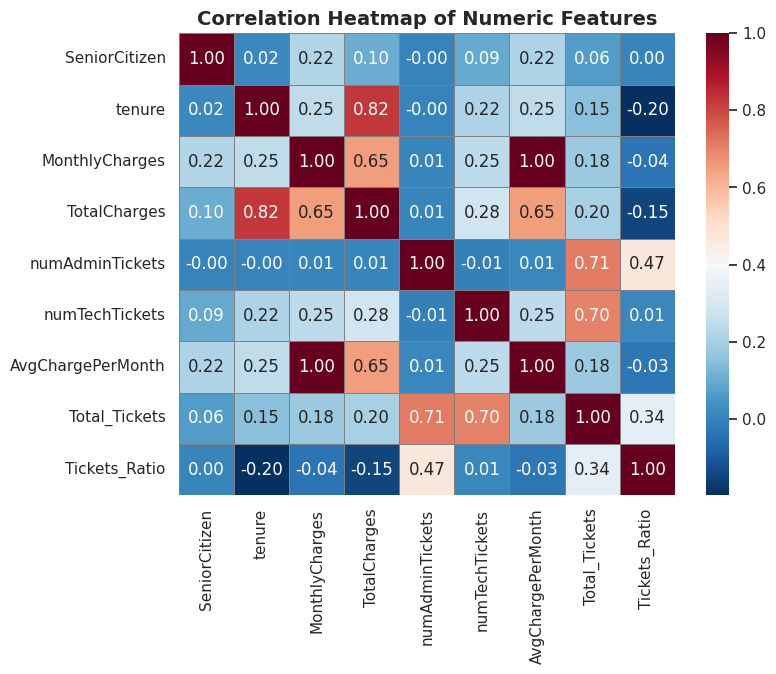

The heatmap shows: Strong relationships between billing-related variables (MonthlyCharges, TotalCharges, AvgChargePerMonth),
Weak or negligible relationships between demographic features (SeniorCitizen) and other numeric features.


In [58]:
sns.set(style="darkgrid")

plt.figure(figsize=(8,6))
sns.heatmap(
    df_churn_rate.corr(numeric_only=True),
    annot=True,
    cmap='RdBu_r',
    fmt=".2f",
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Correlation Heatmap of Numeric Features", fontsize=14, fontweight='bold')

plt.show()

print(f"The heatmap shows: Strong relationships between billing-related variables (MonthlyCharges, TotalCharges, AvgChargePerMonth),\nWeak or negligible relationships between demographic features (SeniorCitizen) and other numeric features.")

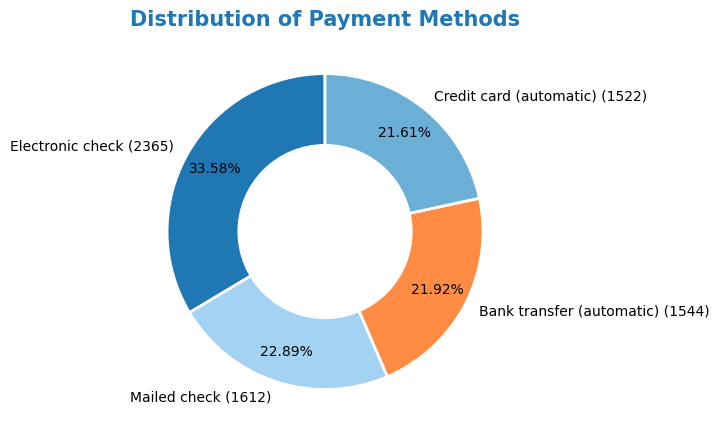

The donut chart shows that most customers use Electronic Check payments,
followed by Automatic Bank Transfers and Credit Cards.
Since earlier analysis showed that electronic check users have higher churn,
this emphasizes the need to promote more convenient auto-payment methods.


In [59]:
soft_blue = '#a3d2f2'
orange = '#ff8c42'
col = '#1f77b4'
sns.set(style="darkgrid")
payment_counts = df_churn_rate['PaymentMethod'].value_counts()

labels = [f"{method} ({count})" for method, count in zip(payment_counts.index, payment_counts.values)]

colors = [col, soft_blue, orange, '#6baed6']

plt.figure(figsize=(7, 7))
wedges, texts, autotexts = plt.pie(
    payment_counts,
    labels=labels,
    autopct='%1.2f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 10, 'color': 'black'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.8
)

centre_circle = plt.Circle((0, 0), 0.55, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribution of Payment Methods', fontsize=15, fontweight='bold', color=col)
plt.tight_layout()
plt.show()
print('''The donut chart shows that most customers use Electronic Check payments,
followed by Automatic Bank Transfers and Credit Cards.
Since earlier analysis showed that electronic check users have higher churn,
this emphasizes the need to promote more convenient auto-payment methods.''')

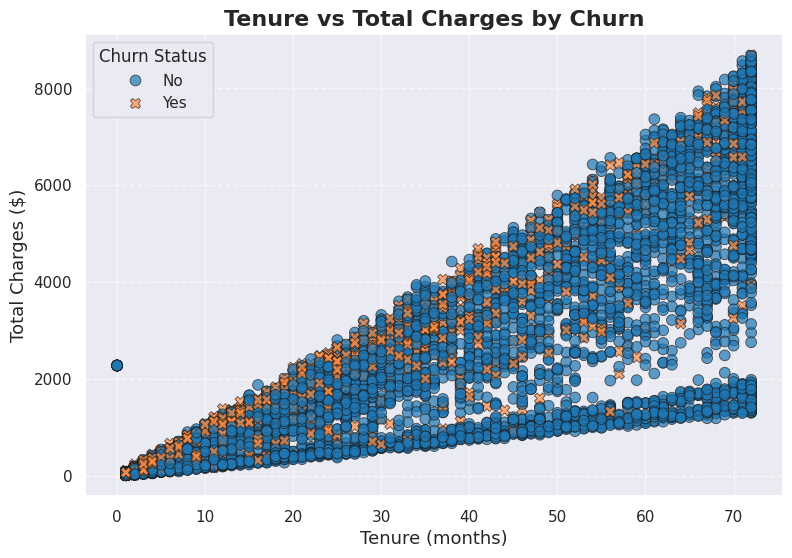

The plot shows a strong positive relationship between tenure and total charges — customers who stay longer spend more,
most churned customers (orange) have shorter tenures and lower total charges,indicating they leave early,
while loyal customers (blue) tend to have higher total charges and stay longer.


In [60]:
sns.set(style="darkgrid")

palette_colors = {'No': '#1f77b4', 'Yes': '#ff8c42'}

plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df_churn_rate,
    x='tenure',
    y='TotalCharges',
    hue='Churn',
    palette=palette_colors,
    style='Churn',
    s=60,
    alpha=0.7,
    edgecolor='k'
)
plt.title("Tenure vs Total Charges by Churn", fontsize=16, fontweight='bold')
plt.xlabel("Tenure (months)", fontsize=13)
plt.ylabel("Total Charges ($)", fontsize=13)

plt.legend(title='Churn Status', title_fontsize=12, fontsize=11, loc='upper left')

plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

print (f"The plot shows a strong positive relationship between tenure and total charges — customers who stay longer spend more,\nmost churned customers (orange) have shorter tenures and lower total charges,indicating they leave early,\nwhile loyal customers (blue) tend to have higher total charges and stay longer.")

/tmp/ipython-input-889097702.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_churn_rate, x='Churn', palette=colors, edgecolor='black')


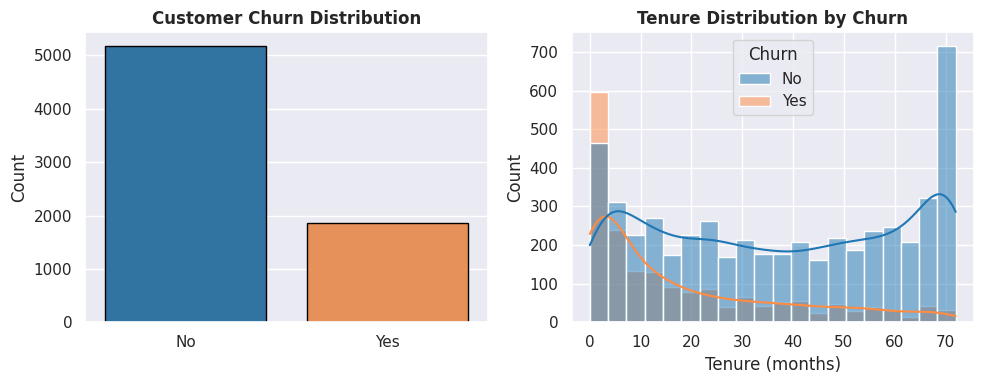

1. Customer Churn Distribution (Left Plot): The majority of customers did not churn (No),
while a smaller portion did churn (Yes). This indicates a class imbalance, with many more retained customers than churned ones.

2. Tenure Distribution by Churn (Right Plot): Churned customers (orange) are mostly concentrated at shorter tenures (0–20 months), 
non-churned customers (blue) are spread across all tenures, especially high at longer tenures (60–70 months),
this suggests that customers who stay longer are less likely to churn, while newer customers leave earlier.


In [61]:
sns.set(style="darkgrid")
colors = ['#1f77b4', '#ff8c42']

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.countplot(data=df_churn_rate, x='Churn', palette=colors, edgecolor='black')
plt.title("Customer Churn Distribution", fontsize=12, fontweight='bold')
plt.xlabel("")
plt.ylabel("Count")

plt.subplot(1,2,2)
sns.histplot(data=df_churn_rate, x='tenure', hue='Churn', bins=20, kde=True, palette=colors)
plt.title("Tenure Distribution by Churn", fontsize=12, fontweight='bold')
plt.xlabel("Tenure (months)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

print(f"1. Customer Churn Distribution (Left Plot): The majority of customers did not churn (No),\nwhile a smaller portion did churn (Yes). This indicates a class imbalance, with many more retained customers than churned ones.\n")
print(f"2. Tenure Distribution by Churn (Right Plot): Churned customers (orange) are mostly concentrated at shorter tenures (0–20 months), \nnon-churned customers (blue) are spread across all tenures, especially high at longer tenures (60–70 months),\nthis suggests that customers who stay longer are less likely to churn, while newer customers leave earlier.")

/tmp/ipython-input-29519469.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_churn_rate, x='Churn', y='MonthlyCharges', palette=colors)


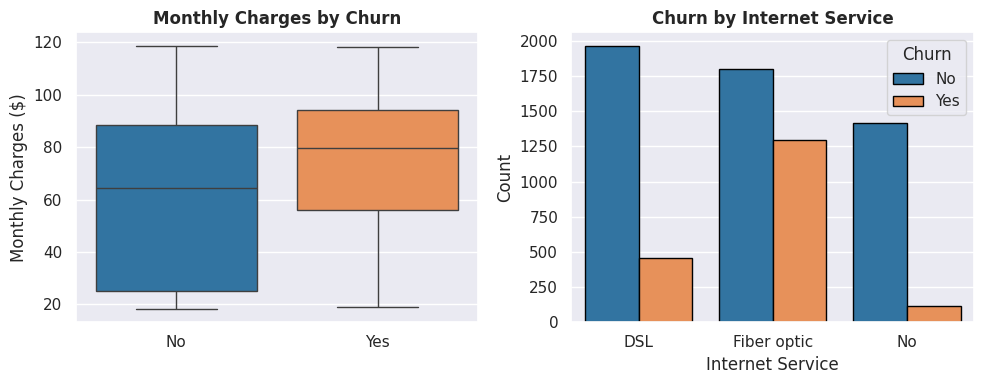

Customers paying higher monthly charges are more likely to leave the company,
those using Fiber optic internet show the highest churn rate, while DSL and customers with no internet service are less likely to churn,
overall, high service costs and Fiber optic subscriptions are key factors linked to customer churn.


In [62]:
plt.figure(figsize=(10,4))
sns.set(style="darkgrid")
plt.subplot(1,2,1)
sns.boxplot(data=df_churn_rate, x='Churn', y='MonthlyCharges', palette=colors)
plt.title("Monthly Charges by Churn", fontsize=12, fontweight='bold')
plt.xlabel("")
plt.ylabel("Monthly Charges ($)")

plt.subplot(1,2,2)
sns.countplot(data=df_churn_rate, x='InternetService', hue='Churn', palette=colors, edgecolor='black')
plt.title("Churn by Internet Service", fontsize=12, fontweight='bold')
plt.xlabel("Internet Service")
plt.ylabel("Count")

plt.tight_layout()
plt.show()
print(f"Customers paying higher monthly charges are more likely to leave the company,\nthose using Fiber optic internet show the highest churn rate, while DSL and customers with no internet service are less likely to churn,\noverall, high service costs and Fiber optic subscriptions are key factors linked to customer churn.")

/tmp/ipython-input-729237962.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_churn_rate, x='Churn', y='numTechTickets', palette=colors)


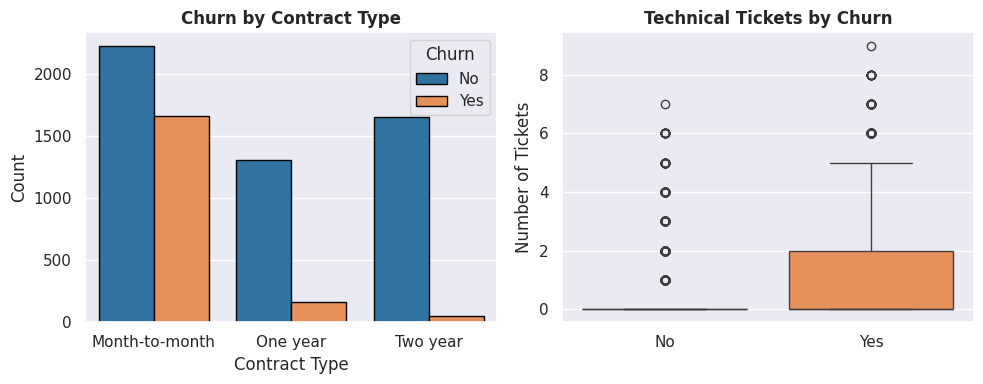

Customers with month-to-month contracts have the highest churn rate compared to those with one-year or two-year contracts ,
longer-term contracts seem to help retain customers, likely because they encourage commitment and satisfaction.
Additionally, customers who churned (“Yes”) tend to have a higher number of technical support tickets,
suggesting that frequent technical issues may be a major factor contributing to churn.


In [63]:
plt.figure(figsize=(10,4))
sns.set(style="darkgrid")
plt.subplot(1,2,1)
sns.countplot(data=df_churn_rate, x='Contract', hue='Churn', palette=colors, edgecolor='black')
plt.title("Churn by Contract Type", fontsize=12, fontweight='bold')
plt.xlabel("Contract Type")
plt.ylabel("Count")

plt.subplot(1,2,2)
sns.boxplot(data=df_churn_rate, x='Churn', y='numTechTickets', palette=colors)
plt.title("Technical Tickets by Churn", fontsize=12, fontweight='bold')
plt.xlabel("")
plt.ylabel("Number of Tickets")

plt.tight_layout()
plt.show()
print(f"Customers with month-to-month contracts have the highest churn rate compared to those with one-year or two-year contracts ,\nlonger-term contracts seem to help retain customers, likely because they encourage commitment and satisfaction.\nAdditionally, customers who churned (“Yes”) tend to have a higher number of technical support tickets,\nsuggesting that frequent technical issues may be a major factor contributing to churn.")

/tmp/ipython-input-1345690691.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_call_center, x='Resolved', palette=colors, edgecolor='black')


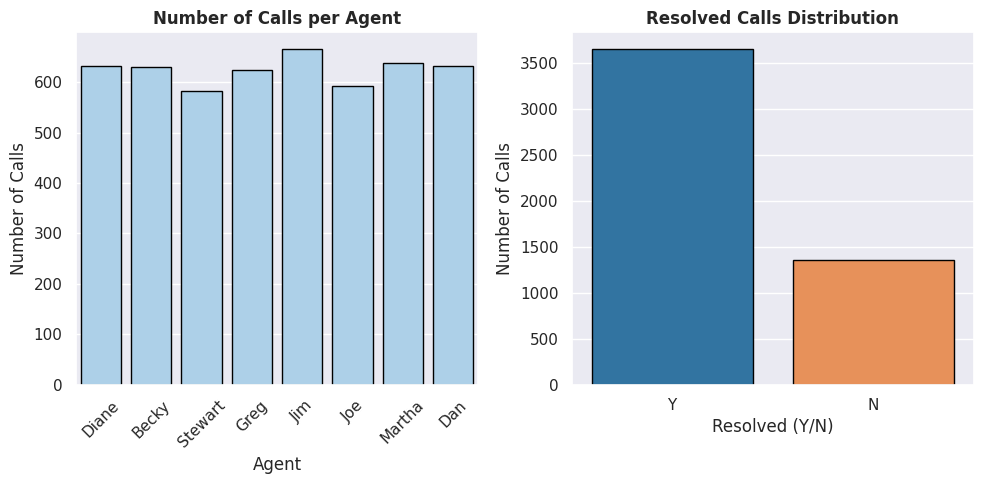

All call center agents handle a similar number of calls, indicating a balanced workload across the team.
However, when looking at call outcomes, the majority of calls are successfully resolved (Y),
while a smaller portion remain unresolved (N).


In [64]:
sns.set(style="darkgrid")
soft_blue = '#a3d2f2'
colors = ['#1f77b4', '#ff8c42']

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.countplot(data=df_call_center, x='Agent', color=soft_blue, edgecolor='black')
plt.title("Number of Calls per Agent", fontsize=12, fontweight='bold')
plt.xlabel("Agent")
plt.ylabel("Number of Calls")
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.countplot(data=df_call_center, x='Resolved', palette=colors, edgecolor='black')
plt.title("Resolved Calls Distribution", fontsize=12, fontweight='bold')
plt.xlabel("Resolved (Y/N)")
plt.ylabel("Number of Calls")

plt.tight_layout()
plt.show()
print(f"All call center agents handle a similar number of calls, indicating a balanced workload across the team.\nHowever, when looking at call outcomes, the majority of calls are successfully resolved (Y),\nwhile a smaller portion remain unresolved (N).")

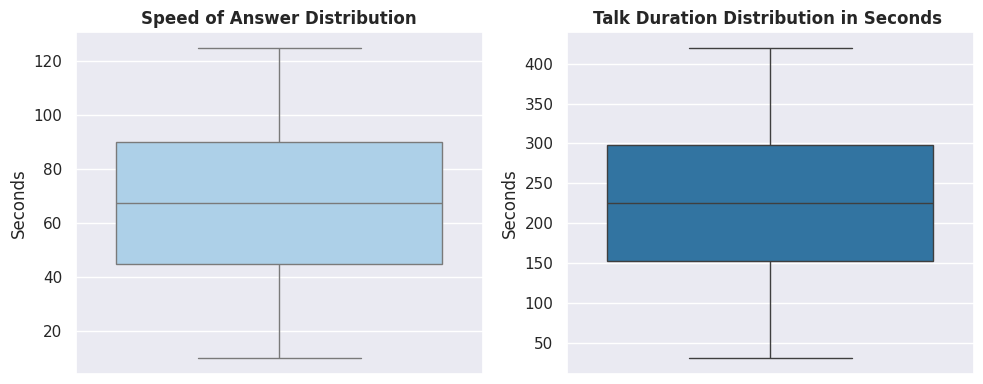

The boxplots show that the call center performs fairly well in response times and experiences varying talk durations,
most calls are answered within about one minute, indicating good responsiveness.
However, talk durations are more variable, with typical calls lasting 3–4 minutes and some taking much longer,
suggesting that while many interactions are straightforward, others require additional time to resolve customer issues.


In [65]:
sns.set(style="darkgrid")

soft_blue = '#a3d2f2'
blue = '#1f77b4'
colors = [soft_blue, blue]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(data=df_call_center, y='Speed of answer in seconds', color=soft_blue)
plt.title("Speed of Answer Distribution", fontsize=12, fontweight='bold')
plt.ylabel("Seconds")

plt.subplot(1,2,2)
sns.boxplot(data=df_call_center, y='TalkDurationSeconds', color=blue)
plt.title("Talk Duration Distribution in Seconds ", fontsize=12, fontweight='bold')
plt.ylabel("Seconds")

plt.tight_layout()
plt.show()

print(f"The boxplots show that the call center performs fairly well in response times and experiences varying talk durations,\nmost calls are answered within about one minute, indicating good responsiveness.\nHowever, talk durations are more variable, with typical calls lasting 3–4 minutes and some taking much longer,\nsuggesting that while many interactions are straightforward, others require additional time to resolve customer issues.")

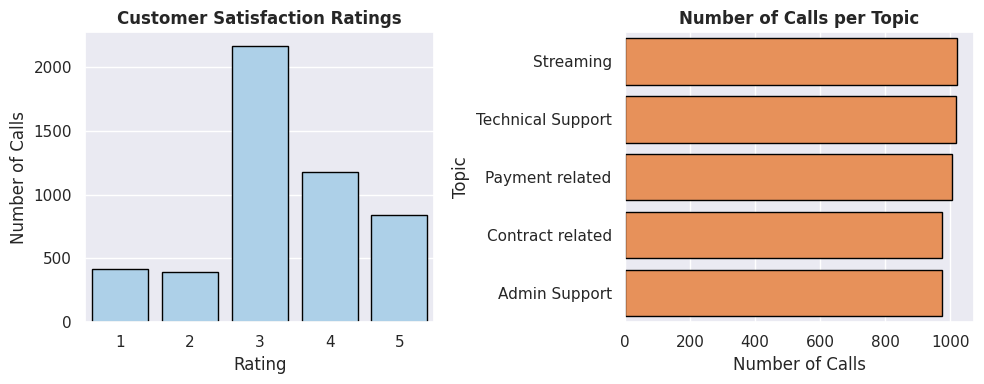

Most customers gave a neutral satisfaction rating (3 out of 5),
showing that their experience was acceptable but not exceptional,
very high and very low ratings were less common, suggesting overall average service performance.
Additionally, the number of calls is evenly distributed across all topics,
meaning customers contact the call center for a wide range of issues rather than one dominant area.


In [66]:
sns.set(style="darkgrid")
soft_blue = '#a3d2f2'
orange = '#ff8c42'

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
rating_order = ['1','2','3','4','5']
sns.countplot(
    data=df_call_center,
    x=df_call_center['Satisfaction rating'].astype(int).astype(str),
    order=rating_order,
    color=soft_blue,
    edgecolor='black'
)
plt.title("Customer Satisfaction Ratings", fontsize=12, fontweight='bold')
plt.xlabel("Rating")
plt.ylabel("Number of Calls")

plt.subplot(1,2,2)
sns.countplot(
    data=df_call_center,
    y='Topic',
    order=df_call_center['Topic'].value_counts().index,
    color=orange,
    edgecolor='black'
)
plt.title("Number of Calls per Topic", fontsize=12, fontweight='bold')
plt.xlabel("Number of Calls")
plt.ylabel("Topic")

plt.tight_layout()
plt.show()
print(f"Most customers gave a neutral satisfaction rating (3 out of 5),\nshowing that their experience was acceptable but not exceptional,\nvery high and very low ratings were less common, suggesting overall average service performance.\nAdditionally, the number of calls is evenly distributed across all topics,\nmeaning customers contact the call center for a wide range of issues rather than one dominant area.")

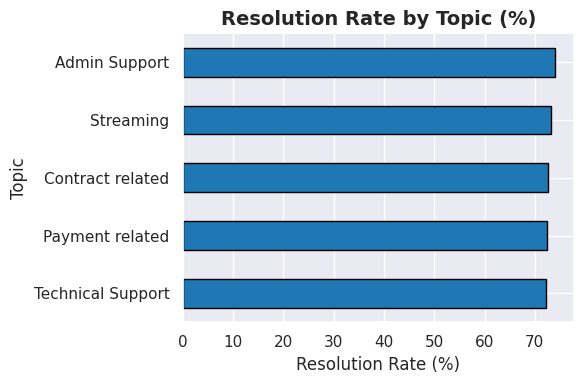

The chart shows that all support topics have similar resolution rates, ranging between 70% and 73%.
Admin Support performs best, while Technical Support is slightly lower.
Overall, the company resolves about 70% of customer issues, indicating consistent but improvable performance across all topics.


In [67]:
col = '#1f77b4'
sns.set(style="darkgrid")
topic_resolved = df_call_center.groupby('Topic')['Resolved'].apply(lambda x: (x=='Y').mean() * 100).sort_values()

plt.figure(figsize=(6,4))
topic_resolved.plot(kind='barh', color=col, edgecolor='black')
plt.title('Resolution Rate by Topic (%)', fontsize=14, fontweight='bold')
plt.xlabel('Resolution Rate (%)')
plt.ylabel('Topic')

plt.tight_layout()
plt.show()
print(f"The chart shows that all support topics have similar resolution rates, ranging between 70% and 73%.\nAdmin Support performs best, while Technical Support is slightly lower.\nOverall, the company resolves about 70% of customer issues, indicating consistent but improvable performance across all topics.")

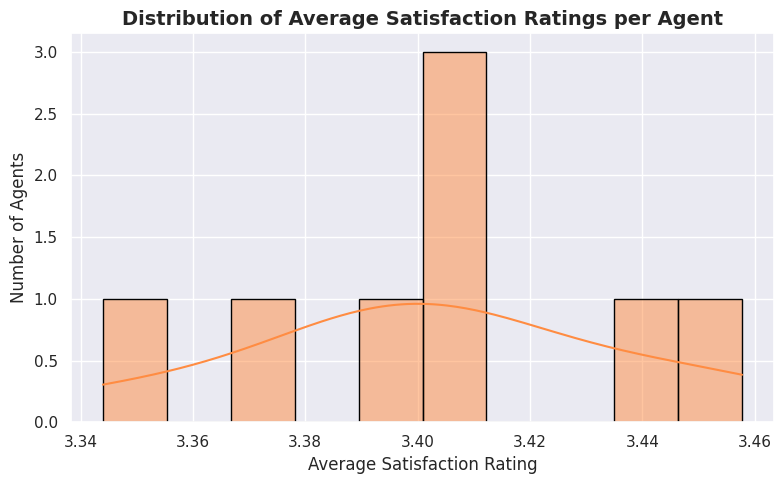

This chart shows how average customer satisfaction ratings are distributed across agents.
Most agents have an average rating around 3.4, which is the peak of the distribution.
Ratings are closely clustered between 3.34 and 3.46, showing that performance among agents is quite consistent.
The distribution is roughly normal (bell-shaped), meaning there are no extreme outliers — neither very low nor very high performers.


In [68]:
sns.set(style="darkgrid")
color_ = '#ff8c42'

agent_rating = df_call_center.groupby('Agent')['Satisfaction rating'].mean()

plt.figure(figsize=(8,5))
sns.histplot(agent_rating, bins=10, color=color_, edgecolor='black', kde=True)
plt.title('Distribution of Average Satisfaction Ratings per Agent', fontsize=14, fontweight='bold')
plt.xlabel('Average Satisfaction Rating')
plt.ylabel('Number of Agents')

plt.tight_layout()
plt.show()
print(f"This chart shows how average customer satisfaction ratings are distributed across agents.\nMost agents have an average rating around 3.4, which is the peak of the distribution.\nRatings are closely clustered between 3.34 and 3.46, showing that performance among agents is quite consistent.\nThe distribution is roughly normal (bell-shaped), meaning there are no extreme outliers — neither very low nor very high performers.")


/tmp/ipython-input-1381900559.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_satisfaction = df_call_center.groupby('SpeedBin')['Satisfaction rating'].mean().reset_index()


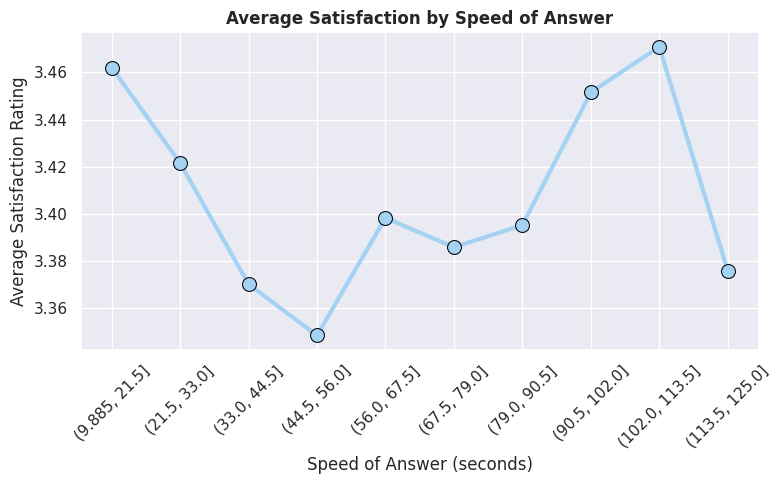

The chart shows that customer satisfaction varies with response speed.
Satisfaction is highest when calls are answered very quickly or after a moderate delay,
and lowest when the response time is in the mid-range (around 40–55 seconds).
Overall, satisfaction remains fairly stable with only small fluctuations.


In [69]:
sns.set(style="darkgrid")
soft_blue = '#a3d2f2'
orange = '#ff8c42'

df_call_center['SpeedBin'] = pd.cut(df_call_center['Speed of answer in seconds'], bins=10)

avg_satisfaction = df_call_center.groupby('SpeedBin')['Satisfaction rating'].mean().reset_index()
avg_satisfaction['SpeedBin'] = avg_satisfaction['SpeedBin'].astype(str)

plt.figure(figsize=(8,5))
sns.lineplot(
    data=avg_satisfaction,
    x='SpeedBin',
    y='Satisfaction rating',
    marker='o',
    color=soft_blue,
    linewidth=3,
    markersize=10,
    markeredgecolor='black'
)
plt.xticks(rotation=45)
plt.title('Average Satisfaction by Speed of Answer', fontsize=12, fontweight='bold')
plt.xlabel('Speed of Answer (seconds)')
plt.ylabel('Average Satisfaction Rating')
plt.tight_layout()
plt.show()
print(f"The chart shows that customer satisfaction varies with response speed.\nSatisfaction is highest when calls are answered very quickly or after a moderate delay,\nand lowest when the response time is in the mid-range (around 40–55 seconds).\nOverall, satisfaction remains fairly stable with only small fluctuations.")

In [70]:
sns.set(style="darkgrid")
soft_blue = '#a3d2f2'
orange = '#ff8c42'
col = '#1f77b4'

fig = px.scatter(
    df_churn_rate,
    x='tenure',
    y='MonthlyCharges',
    color='Churn',
    size='TotalCharges',
    hover_data=['customerID', 'Contract', 'PaymentMethod'],
    title='Customer Tenure vs Monthly Charges (Interactive)',
    color_discrete_sequence=[col, orange],
)

fig.update_layout(
    title_font_size=20,
    plot_bgcolor='white',
    legend_title_text='Churned?',
    font=dict(family="Arial", size=12, color=col),
    template='plotly_white',
    title_font_color=col,
)

fig.update_xaxes(showgrid=True, gridwidth=0.5, gridcolor=soft_blue)
fig.update_yaxes(showgrid=True, gridwidth=0.5, gridcolor=soft_blue)

fig.show()
print(f"The visualization reveals a clear relationship between customer longevity and churn behavior,\ncustomers with shorter tenures (under 20 months) show a higher churn rate,\nsuggesting that early dissatisfaction or pricing concerns lead to cancellations.\nIn contrast, customers with longer tenures tend to remain loyal,\nindicating improved satisfaction or commitment over time.\n")
print(f"Overall, churn is more common among newer customers paying moderate-to-high monthly charges,\nhighlighting the importance of improving onboarding experiences, service quality,\nand pricing strategies to reduce early churn and enhance long-term retention.")


The visualization reveals a clear relationship between customer longevity and churn behavior,
customers with shorter tenures (under 20 months) show a higher churn rate,
suggesting that early dissatisfaction or pricing concerns lead to cancellations.
In contrast, customers with longer tenures tend to remain loyal,
indicating improved satisfaction or commitment over time.

Overall, churn is more common among newer customers paying moderate-to-high monthly charges,
highlighting the importance of improving onboarding experiences, service quality,
and pricing strategies to reduce early churn and enhance long-term retention.


# **Findings, Conclusions, and Insights**

The analysis revealed several key insights into telecom customer behavior and call-center performance.
Customers with shorter tenures and higher monthly charges are significantly more likely to churn, suggesting early dissatisfaction or price sensitivity as main drivers.
In contrast, long-term customers tend to remain loyal, showing that retention improves with service duration.

Exploration of call-center data indicated that customer satisfaction decreases as response times increase, emphasizing the need for faster support to enhance user experience.
The correlation analysis highlighted that features like contract type, payment method, and total charges strongly influence churn likelihood.

Overall, the findings suggest that telecom companies can reduce churn by improving early customer engagement, optimizing pricing strategies,
and investing in responsive, efficient support channels. These actions could lead to higher satisfaction, loyalty, and long-term profitability.



# **Thank You!**